# E-Commerce Customer & Sales Analytics — Business Case Study

**Dataset:** 5,000 customers · 30k+ orders · 55k+ order line items · Jan 2023 – Aug 2026, spanning
10 categories, 5 acquisition channels, and 3 shipping tiers.

This notebook is the analysis engine behind `CASE_STUDY.md` and the dashboard — every figure
quoted in either of those documents is computed directly in the cells below, not hand-typed.
Structure: Revenue -> Customers -> Retention -> Marketing -> Operations -> Key Findings.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3, json

pd.set_option("display.width", 120)

BLUES = ["#0B3D6B", "#1B5FA8", "#3E82C9", "#7FB0DE", "#B8D4EE"]
NAVY = "#0A2540"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": NAVY, "axes.labelcolor": NAVY, "text.color": NAVY,
    "xtick.color": NAVY, "ytick.color": NAVY,
    "axes.grid": True, "grid.color": "#E3EEFC", "grid.linewidth": 0.9,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10.5, "figure.dpi": 130,
})

DATA = "../data"
con = sqlite3.connect(f"{DATA}/ecommerce.db")

customers = pd.read_csv(f"{DATA}/customers.csv", parse_dates=["first_order_date"])
products  = pd.read_csv(f"{DATA}/products.csv")
orders    = pd.read_csv(f"{DATA}/orders.csv", parse_dates=["order_date", "delivery_date"])
items     = pd.read_csv(f"{DATA}/order_items.csv")
returns   = pd.read_csv(f"{DATA}/returns.csv", parse_dates=["return_date"])
spend     = pd.read_csv(f"{DATA}/marketing_spend.csv", parse_dates=["month"])

items_full = (items.merge(orders[["order_id", "customer_id", "order_date"]], on="order_id")
                    .merge(products[["product_id", "category", "product_name"]], on="product_id"))

SNAPSHOT = pd.Timestamp("2026-08-31")
results = {}

print(f"Orders: {len(orders):,} | Line items: {len(items):,} | Customers: {len(customers):,} | Products: {len(products):,}")
print(f"Date range: {orders.order_date.min().date()} to {orders.order_date.max().date()}")
print(f"Total net revenue: ${items.line_net_revenue.sum():,.2f}")

Orders: 31,332 | Line items: 57,801 | Customers: 5,000 | Products: 294
Date range: 2023-01-01 to 2026-08-31
Total net revenue: $9,718,090.91


## 1. Revenue

Monthly trend, category mix, and average order value. Revenue is always **net of discounts**
(`line_net_revenue`), which is what should drive any margin or profitability read.

AOV: $310.17  |  Overall margin: 41.88%  |  Peak month: 2025-12 ($335,257)


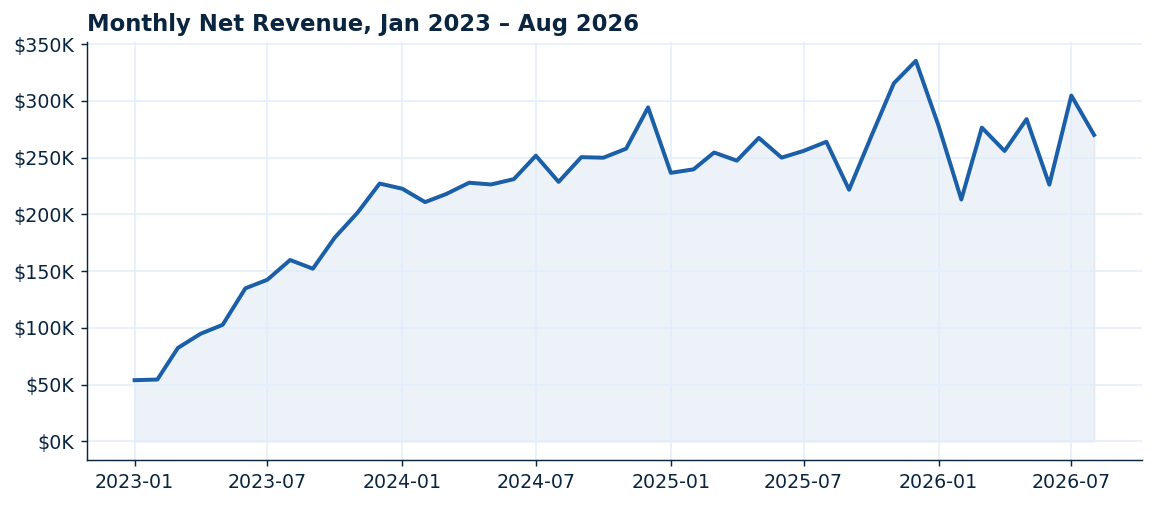

In [2]:
monthly = items_full.copy()
monthly["month"] = monthly["order_date"].values.astype("datetime64[M]")
rev_trend = monthly.groupby("month").agg(net_revenue=("line_net_revenue", "sum"),
                                          orders=("order_id", "nunique")).reset_index()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(rev_trend.month, rev_trend.net_revenue, color=BLUES[1], linewidth=2.2)
ax.fill_between(rev_trend.month, rev_trend.net_revenue, color=BLUES[1], alpha=0.08)
ax.set_title("Monthly Net Revenue, Jan 2023 – Aug 2026", loc="left", fontweight="bold")
ax.yaxis.set_major_formatter(lambda x, pos: f"${x/1000:.0f}K")
plt.tight_layout()
plt.show()

results["total_net_revenue"] = round(items.line_net_revenue.sum(), 2)
results["total_orders"] = int(orders.order_id.nunique())
results["aov"] = round(items.line_net_revenue.sum() / orders.order_id.nunique(), 2)
results["overall_margin_pct"] = round(100 * items.line_profit.sum() / items.line_net_revenue.sum(), 2)
peak = rev_trend.loc[rev_trend.net_revenue.idxmax()]
results["peak_month"] = str(peak.month.date())[:7]
results["peak_month_revenue"] = round(peak.net_revenue, 2)
print(f"AOV: ${results['aov']}  |  Overall margin: {results['overall_margin_pct']}%  |  Peak month: {results['peak_month']} (${results['peak_month_revenue']:,.0f})")

                        net_revenue      profit  margin_pct
category                                                   
Furniture                3110686.62  1256608.48       40.40
Electronics              1885729.39   581417.70       30.83
Sports & Outdoors        1161830.73   525413.97       45.22
Home & Kitchen            970308.48   418283.33       43.11
Footwear                  907277.01   459392.78       50.63
Apparel & Clothing        468032.59   254788.36       54.44
Beauty & Personal Care    384360.36   225469.13       58.66
Toys & Games              356691.17   167170.85       46.87
Grocery & Gourmet         265007.80    95822.91       36.16
Books & Media             208166.76    85603.36       41.12


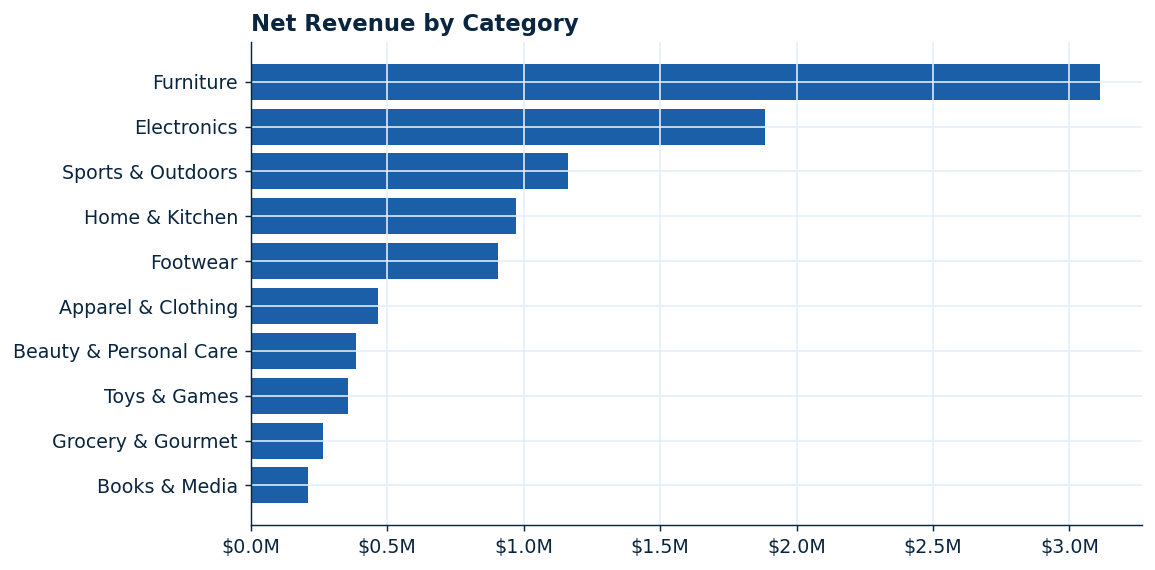

In [3]:
cat_rev = items_full.groupby("category").agg(
    net_revenue=("line_net_revenue", "sum"), profit=("line_profit", "sum")
).assign(margin_pct=lambda d: 100 * d.profit / d.net_revenue).sort_values("net_revenue", ascending=False)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(cat_rev.index[::-1], cat_rev.net_revenue[::-1], color=BLUES[1])
ax.set_title("Net Revenue by Category", loc="left", fontweight="bold")
ax.xaxis.set_major_formatter(lambda x, pos: f"${x/1e6:.1f}M")
plt.tight_layout()
plt.show()

results["category_revenue"] = cat_rev.round(2).reset_index().to_dict(orient="records")
print(cat_rev.round(2))

## 2. Customers — New vs. Returning, RFM Segmentation, CLV

RFM (Recency / Frequency / Monetary) scoring on quintiles, mapped to six standard segments.
This is where "who actually drives the business" becomes visible.

In [4]:
order_seq = orders.sort_values("order_date").copy()
order_seq["order_rank"] = order_seq.groupby("customer_id").cumcount() + 1
new_vs_ret = (items.merge(order_seq[["order_id", "order_rank"]], on="order_id")
                    .assign(customer_type=lambda d: np.where(d.order_rank == 1, "New (1st order)", "Returning (2nd+)"))
                    .groupby("customer_type").line_net_revenue.sum())
results["new_customer_revenue_pct"] = round(100 * new_vs_ret["New (1st order)"] / new_vs_ret.sum(), 1)
results["returning_customer_revenue_pct"] = round(100 - results["new_customer_revenue_pct"], 1)
print(new_vs_ret.round(2), "\n")
print(f"Returning customers drive {results['returning_customer_revenue_pct']}% of net revenue")

customer_type
New (1st order)     1558304.40
Returning (2nd+)    8159786.51
Name: line_net_revenue, dtype: float64 

Returning customers drive 84.0% of net revenue


                 customers  avg_clv  total_revenue  pct_customers  pct_revenue
segment                                                                       
Loyal Customers       1114  3522.06     3923572.23           22.3         40.4
Champions              886  4069.81     3605856.05           17.7         37.1
Need Attention         970   992.86      963070.00           19.4          9.9
At Risk                373  1231.30      459274.84            7.5          4.7
Hibernating            962   446.20      429248.22           19.2          4.4
New / Promising        695   484.99      337069.57           13.9          3.5

Top 2 segments (Loyal Customers + Champions) = 40.0% of customers but 77.5% of revenue
Average CLV: $1943.62  |  Repeat-purchase rate: 75.84%


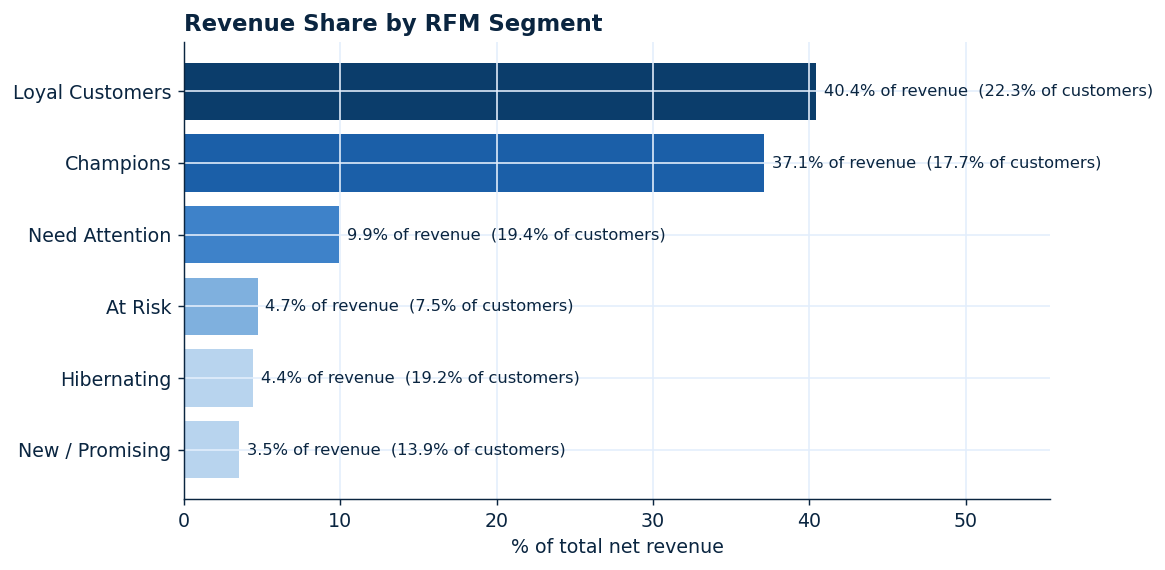

In [5]:
cust_agg = items_full.groupby("customer_id").agg(
    last_order=("order_date", "max"), frequency=("order_id", "nunique"), monetary=("line_net_revenue", "sum")
).reset_index()
cust_agg["recency_days"] = (SNAPSHOT - cust_agg["last_order"]).dt.days
cust_agg["R"] = pd.qcut(cust_agg.recency_days, 5, labels=[5, 4, 3, 2, 1]).astype(int)
cust_agg["F"] = pd.qcut(cust_agg.frequency.rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
cust_agg["M"] = pd.qcut(cust_agg.monetary, 5, labels=[1, 2, 3, 4, 5]).astype(int)

def rfm_segment(row):
    R, F = row.R, row.F
    if R >= 4 and F >= 4: return "Champions"
    if F >= 4: return "Loyal Customers"
    if R <= 2 and F >= 3: return "At Risk"
    if R >= 4 and F <= 2: return "New / Promising"
    if R <= 2 and F <= 2: return "Hibernating"
    return "Need Attention"

cust_agg["segment"] = cust_agg.apply(rfm_segment, axis=1)
seg = cust_agg.groupby("segment").agg(customers=("customer_id", "count"), avg_clv=("monetary", "mean"),
                                       total_revenue=("monetary", "sum"))
seg["pct_customers"] = round(100 * seg.customers / seg.customers.sum(), 1)
seg["pct_revenue"] = round(100 * seg.total_revenue / seg.total_revenue.sum(), 1)
seg = seg.sort_values("total_revenue", ascending=False).round(2)

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = [BLUES[min(i, 4)] for i in range(len(seg))]
ax.barh(seg.index[::-1], seg.pct_revenue[::-1], color=colors[::-1])
for i, (v, c) in enumerate(zip(seg.pct_revenue[::-1], seg.pct_customers[::-1])):
    ax.text(v + 0.5, i, f"{v}% of revenue  ({c}% of customers)", va="center", fontsize=9)
ax.set_xlim(0, max(seg.pct_revenue) + 15)
ax.set_title("Revenue Share by RFM Segment", loc="left", fontweight="bold")
ax.set_xlabel("% of total net revenue")
plt.tight_layout()
plt.show()

results["rfm_segments"] = seg.reset_index().to_dict(orient="records")
results["overall_clv"] = round(cust_agg.monetary.mean(), 2)
results["repeat_purchase_rate_pct"] = round(100 * (cust_agg.frequency >= 2).mean(), 2)
print(seg)
top2_rev = seg.iloc[:2].pct_revenue.sum()
top2_cust = seg.iloc[:2].pct_customers.sum()
results["top2_segment_revenue_share_pct"] = round(top2_rev, 1)
results["top2_segment_customer_share_pct"] = round(top2_cust, 1)
print(f"\nTop 2 segments ({seg.index[0]} + {seg.index[1]}) = {top2_cust:.1f}% of customers but {top2_rev:.1f}% of revenue")
print(f"Average CLV: ${results['overall_clv']}  |  Repeat-purchase rate: {results['repeat_purchase_rate_pct']}%")

## 3. Retention — Cohort Analysis & Churn

Customers are grouped into monthly cohorts by first purchase date. For each cohort we track what
share is still active in month 1, 2, 3... after acquisition. Recent cohorts (last 6 months) are
excluded from the "mature" average since they haven't had time to re-purchase yet.

Average retention curve (mature cohorts, months 0-6):
month_number
0    100.0
1     33.8
2     33.1
3     33.2
4     31.1
5     30.3
6     28.6
dtype: float64

180-day churn rate: 68.94%


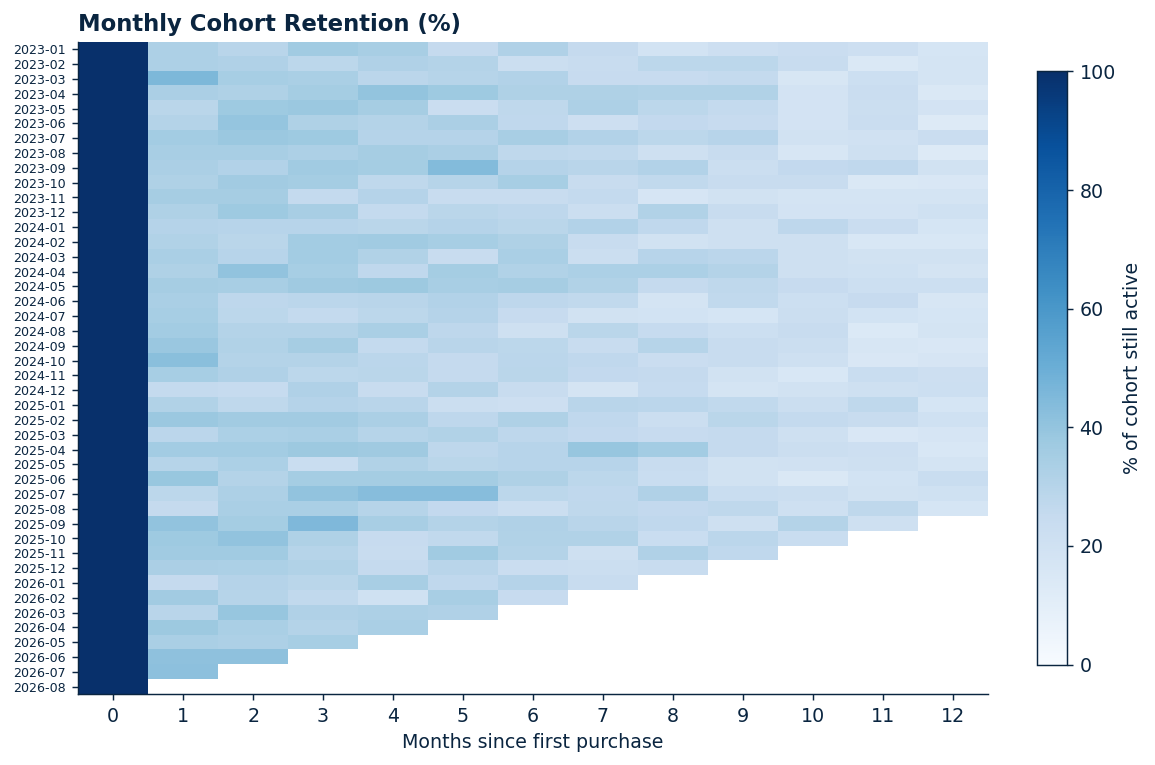

In [6]:
first_order = orders.groupby("customer_id").order_date.min().rename("cohort_date")
om = orders.merge(first_order, on="customer_id")
om["cohort_month"] = om.cohort_date.values.astype("datetime64[M]")
om["order_month"] = om.order_date.values.astype("datetime64[M]")
om["month_number"] = ((om.order_month.dt.year - om.cohort_month.dt.year) * 12 +
                       (om.order_month.dt.month - om.cohort_month.dt.month))

cohort_size = om[om.month_number == 0].groupby("cohort_month").customer_id.nunique()
cohort_counts = om.groupby(["cohort_month", "month_number"]).customer_id.nunique().reset_index()
cohort_counts = cohort_counts.merge(cohort_size.rename("cohort_size"), on="cohort_month")
cohort_counts["retention_pct"] = 100 * cohort_counts.customer_id / cohort_counts.cohort_size

pivot = cohort_counts.pivot(index="cohort_month", columns="month_number", values="retention_pct")
mature = pivot[pivot.index <= "2025-12-01"]

fig, ax = plt.subplots(figsize=(9, 6))
show = pivot.iloc[:, :13]
im = ax.imshow(show.values, cmap="Blues", vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(show.shape[1])); ax.set_xticklabels(show.columns)
ax.set_yticks(range(show.shape[0])); ax.set_yticklabels([str(m)[:7] for m in show.index], fontsize=7)
ax.set_xlabel("Months since first purchase"); ax.set_title("Monthly Cohort Retention (%)", loc="left", fontweight="bold")
ax.grid(False)
plt.colorbar(im, ax=ax, label="% of cohort still active", fraction=0.03)
plt.tight_layout()
plt.show()

avg_curve = mature.mean(axis=0).round(1)
results["cohort_month1_retention_pct"] = float(avg_curve.get(1, np.nan))
results["cohort_month3_retention_pct"] = float(avg_curve.get(3, np.nan))
results["cohort_month6_retention_pct"] = float(avg_curve.get(6, np.nan))
results["churn_rate_180d_pct"] = round(100 * (cust_agg.recency_days > 180).mean(), 2)
print("Average retention curve (mature cohorts, months 0-6):")
print(avg_curve.iloc[:7])
print(f"\n180-day churn rate: {results['churn_rate_180d_pct']}%")

## 4. Marketing — Discounting vs. Margin, Acquisition Channel Performance

                 net_revenue      profit  items  margin_pct
band                                                       
0% (full price)   4704881.22  2206068.06  25428       46.89
1-10%             2514107.99  1100997.65  14644       43.79
11-25%            1735413.89   609974.46  11659       35.15
26-40%             763687.81   152930.70   6070       20.03

Orders discounted 26-40% run 26.9 margin points (57.3% relatively) below full-price orders.


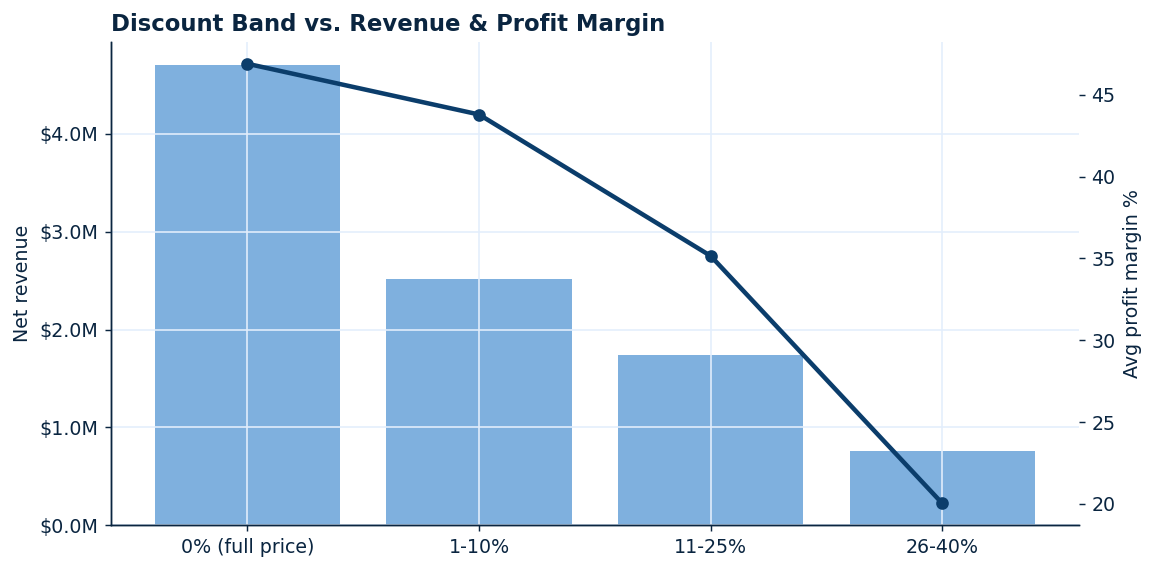

In [7]:
disc = items_full.merge(orders[["order_id", "discount_pct"]], on="order_id")
disc["band"] = pd.cut(disc.discount_pct, bins=[-0.01, 0, 0.10, 0.25, 1.0],
                       labels=["0% (full price)", "1-10%", "11-25%", "26-40%"])
band_summary = disc.groupby("band", observed=True).agg(
    net_revenue=("line_net_revenue", "sum"), profit=("line_profit", "sum"), items=("order_item_id", "count")
).assign(margin_pct=lambda d: round(100 * d.profit / d.net_revenue, 2))

fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.bar(band_summary.index.astype(str), band_summary.net_revenue, color=BLUES[3], label="Net revenue")
ax1.yaxis.set_major_formatter(lambda x, pos: f"${x/1e6:.1f}M")
ax1.set_ylabel("Net revenue")
ax2 = ax1.twinx()
ax2.plot(band_summary.index.astype(str), band_summary.margin_pct, color=BLUES[0], marker="o", linewidth=2.5)
ax2.set_ylabel("Avg profit margin %")
ax2.grid(False)
ax1.set_title("Discount Band vs. Revenue & Profit Margin", loc="left", fontweight="bold")
plt.tight_layout()
plt.show()

results["discount_bands"] = band_summary.round(2).reset_index().to_dict(orient="records")
full_price_margin = band_summary.loc["0% (full price)", "margin_pct"]
high_disc_margin = band_summary.loc["26-40%", "margin_pct"]
results["margin_full_price"] = float(full_price_margin)
results["margin_high_discount"] = float(high_disc_margin)
results["margin_point_gap_high_vs_full"] = round(float(full_price_margin - high_disc_margin), 1)
results["margin_relative_pct_lower"] = round(100 * (full_price_margin - high_disc_margin) / full_price_margin, 1)
print(band_summary.round(2))
print(f"\nOrders discounted 26-40% run {results['margin_point_gap_high_vs_full']} margin points "
      f"({results['margin_relative_pct_lower']}% relatively) below full-price orders.")

                     customers  avg_orders  ...     cac  ltv_cac_ratio
acquisition_channel                         ...                       
Referral                   427        7.96  ...   55.39          42.48
Organic Search            1727        6.90  ...   41.14          52.20
Direct                    1008        6.39  ...     NaN            NaN
Email Marketing            609        6.78  ...   71.60          27.12
Paid Social               1229        4.43  ...  309.01           4.69

[5 rows x 6 columns]


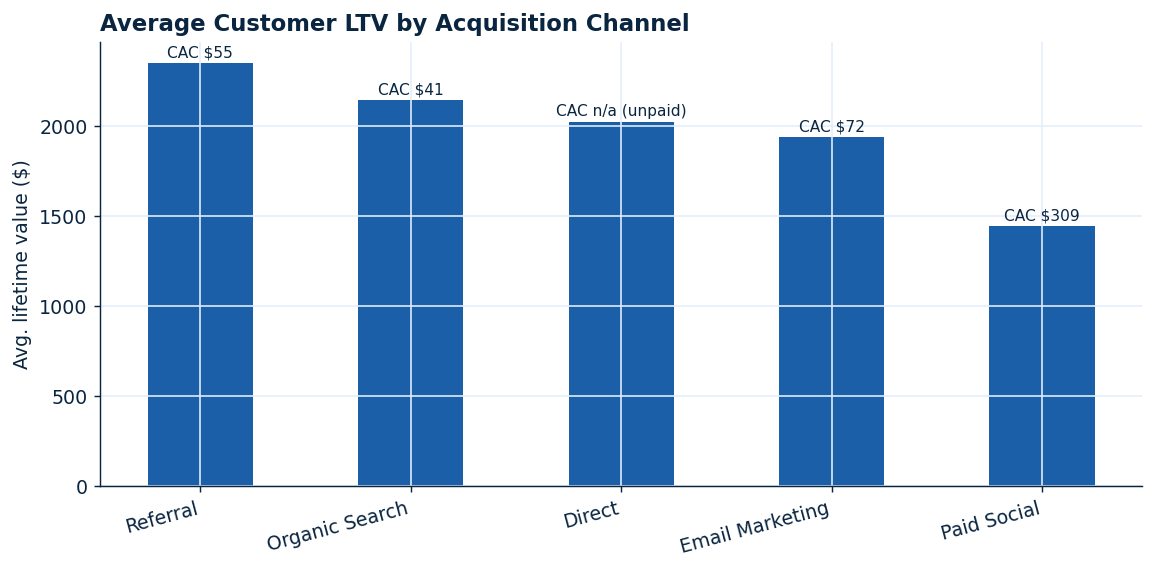

In [8]:
cust_full = customers.merge(cust_agg[["customer_id", "frequency", "monetary"]], on="customer_id", how="left").fillna(0)
chan = cust_full.groupby("acquisition_channel").agg(customers=("customer_id", "count"),
                                                      avg_orders=("frequency", "mean"),
                                                      avg_ltv=("monetary", "mean"))
one_and_done = cust_full[cust_full.frequency >= 1].groupby("acquisition_channel").frequency.apply(lambda f: 100 * (f == 1).mean())
chan["pct_one_and_done"] = one_and_done.round(1)

customers_m = customers.copy()
customers_m["acq_month"] = customers_m.first_order_date.values.astype("datetime64[M]")
new_by_month = customers_m.groupby(["acquisition_channel", "acq_month"]).size().rename("new_customers").reset_index()
spend_j = spend.rename(columns={"channel": "acquisition_channel"}).merge(
    new_by_month, left_on=["acquisition_channel", "month"], right_on=["acquisition_channel", "acq_month"], how="left")
cac = spend_j.groupby("acquisition_channel").apply(lambda d: d.spend.sum() / d.new_customers.sum() if d.new_customers.sum() else np.nan)
chan["cac"] = cac.round(2)
chan["ltv_cac_ratio"] = round(chan.avg_ltv / chan.cac, 2)
chan = chan.round(2).sort_values("avg_ltv", ascending=False)

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(chan))
ax.bar(x, chan.avg_ltv, color=BLUES[1], width=0.5)
ax.set_xticks(x); ax.set_xticklabels(chan.index, rotation=15, ha="right")
ax.set_ylabel("Avg. lifetime value ($)")
ax.set_title("Average Customer LTV by Acquisition Channel", loc="left", fontweight="bold")
for i, (ltv, cac_v) in enumerate(zip(chan.avg_ltv, chan.cac)):
    label = f"CAC ${cac_v:.0f}" if pd.notna(cac_v) else "CAC n/a (unpaid)"
    ax.text(i, ltv + 30, label, ha="center", fontsize=8.5)
plt.tight_layout()
plt.show()

results["channel_performance"] = chan.reset_index().to_dict(orient="records")
print(chan)

## 5. Operations — Returns & Delivery Performance

                        items_sold  returned  return_rate_pct
category                                                     
Apparel & Clothing            5728       626            10.93
Footwear                      5935       605            10.19
Furniture                     5980       433             7.24
Electronics                   5242       265             5.06
Sports & Outdoors             5689       251             4.41
Home & Kitchen                5709       223             3.91
Toys & Games                  6066       210             3.46
Beauty & Personal Care        5747       139             2.42
Books & Media                 6067       100             1.65
Grocery & Gourmet             5638        58             1.03

Top return-rate products (min 40 units sold):
                                          units_sold  returned  return_rate_pct
product_name          category                                                 
Denim Jacket Deluxe   Apparel & Clothing         

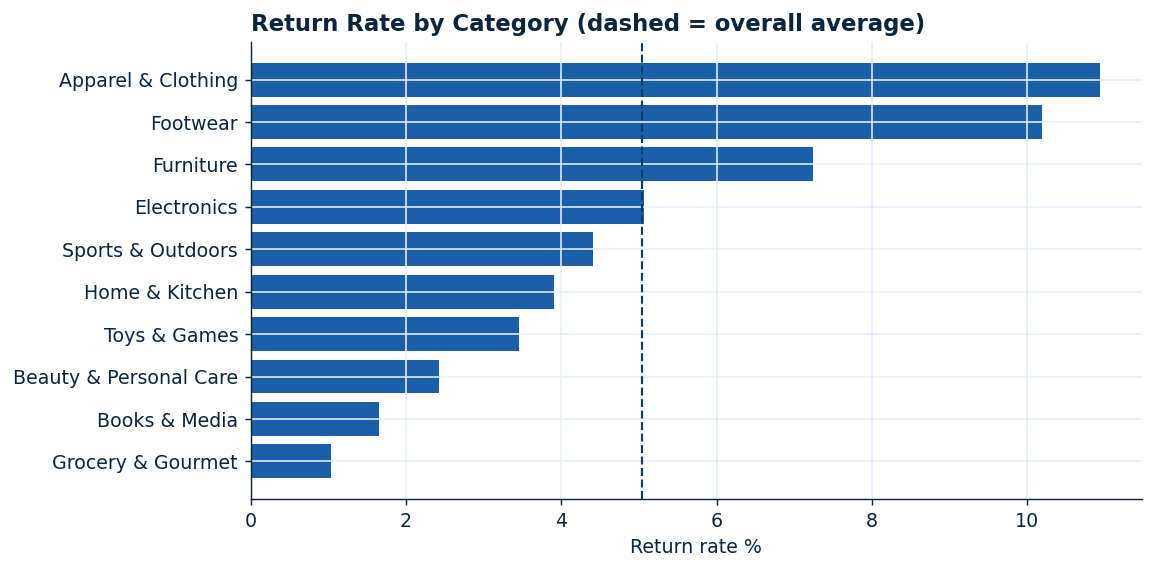

In [9]:
ret_by_cat = items_full.merge(returns[["order_item_id", "return_id"]], on="order_item_id", how="left")
cat_ret = ret_by_cat.groupby("category").agg(items_sold=("order_item_id", "count"),
                                              returned=("return_id", "count"))
cat_ret["return_rate_pct"] = round(100 * cat_ret.returned / cat_ret.items_sold, 2)
cat_ret = cat_ret.sort_values("return_rate_pct", ascending=False)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(cat_ret.index[::-1], cat_ret.return_rate_pct[::-1], color=BLUES[1])
ax.axvline(cat_ret.returned.sum() / cat_ret.items_sold.sum() * 100, color=BLUES[0], linestyle="--", linewidth=1.2)
ax.set_title("Return Rate by Category (dashed = overall average)", loc="left", fontweight="bold")
ax.set_xlabel("Return rate %")
plt.tight_layout()
plt.show()

results["return_rate_by_category"] = cat_ret.round(2).reset_index().to_dict(orient="records")
results["overall_return_rate_pct"] = round(100 * len(returns) / len(items), 2)
top_ret_products = (ret_by_cat.groupby(["product_name", "category"]).agg(
    units_sold=("order_item_id", "count"), returned=("return_id", "count")).query("units_sold >= 40")
    .assign(return_rate_pct=lambda d: round(100 * d.returned / d.units_sold, 1))
    .sort_values("return_rate_pct", ascending=False).head(8))
results["top_return_products"] = top_ret_products.reset_index().round(1).to_dict(orient="records")
print(cat_ret.round(2))
print("\nTop return-rate products (min 40 units sold):")
print(top_ret_products)

                 orders  avg_days  pct_on_time  pct_delayed
shipping_method                                            
Express            7815      2.85         63.4          4.6
Same-Day           3094      1.18         65.0          2.5
Standard          20423      6.53         61.1          7.1

Return rate — on-time/minor delay: 4.94% vs. significantly delayed: 6.55%


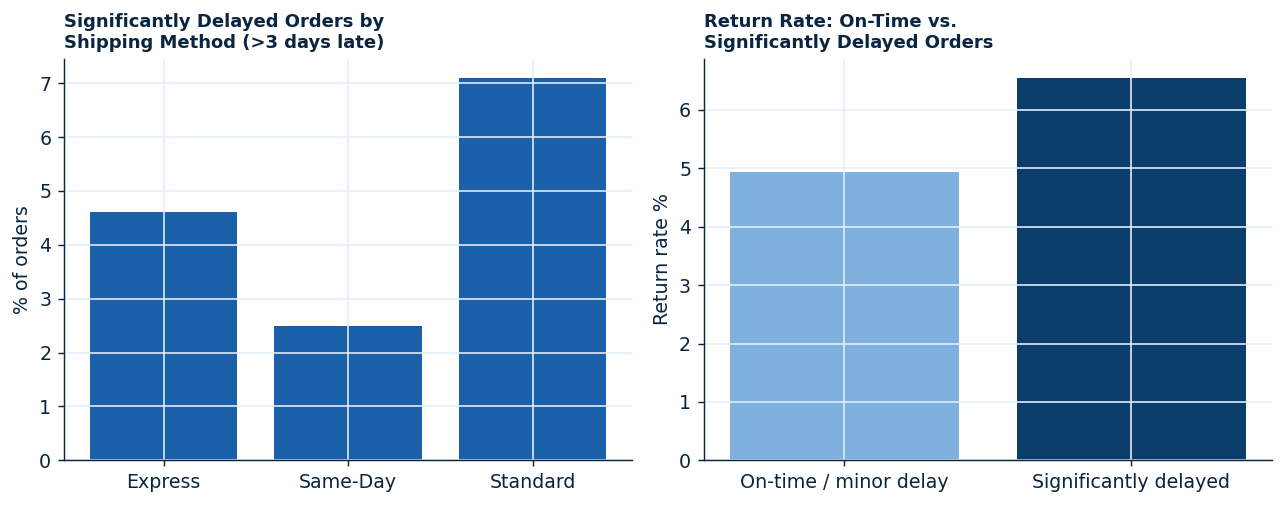

In [10]:
delivery = orders.copy()
delivery["on_time"] = delivery.actual_delivery_days <= delivery.promised_delivery_days
delivery["significantly_delayed"] = (delivery.actual_delivery_days - delivery.promised_delivery_days) > 3
ship_perf = delivery.groupby("shipping_method").agg(
    orders=("order_id", "count"), avg_days=("actual_delivery_days", "mean"),
    pct_on_time=("on_time", "mean"), pct_delayed=("significantly_delayed", "mean"))
ship_perf[["pct_on_time", "pct_delayed"]] = (ship_perf[["pct_on_time", "pct_delayed"]] * 100).round(1)
ship_perf["avg_days"] = ship_perf.avg_days.round(2)

items_delay = items.merge(orders[["order_id", "significantly_delayed" if "significantly_delayed" in orders.columns else "actual_delivery_days", "promised_delivery_days"]], on="order_id") \
    if "significantly_delayed" in orders.columns else items.merge(
        orders[["order_id", "actual_delivery_days", "promised_delivery_days"]], on="order_id")
items_delay["significantly_delayed"] = (items_delay.actual_delivery_days - items_delay.promised_delivery_days) > 3
items_delay = items_delay.merge(returns[["order_item_id", "return_id"]], on="order_item_id", how="left")
delay_ret = items_delay.groupby("significantly_delayed").apply(lambda d: 100 * d.return_id.notna().mean()).round(2)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(ship_perf.index, ship_perf.pct_delayed, color=BLUES[1])
axes[0].set_title("Significantly Delayed Orders by\nShipping Method (>3 days late)", loc="left", fontsize=10, fontweight="bold")
axes[0].set_ylabel("% of orders")
axes[1].bar(["On-time / minor delay", "Significantly delayed"], delay_ret.values, color=[BLUES[3], BLUES[0]])
axes[1].set_title("Return Rate: On-Time vs.\nSignificantly Delayed Orders", loc="left", fontsize=10, fontweight="bold")
axes[1].set_ylabel("Return rate %")
plt.tight_layout()
plt.show()

results["delivery_by_shipping_method"] = ship_perf.reset_index().to_dict(orient="records")
results["return_rate_on_time_pct"] = float(delay_ret.get(False, np.nan))
results["return_rate_delayed_pct"] = float(delay_ret.get(True, np.nan))
print(ship_perf)
print(f"\nReturn rate — on-time/minor delay: {results['return_rate_on_time_pct']}% vs. significantly delayed: {results['return_rate_delayed_pct']}%")

## 6. Key Findings Summary

Condensed version of everything above — the same numbers feed `CASE_STUDY.md` and the dashboard.

In [11]:
print("KEY METRICS")
print("=" * 60)
for k in ["total_net_revenue", "total_orders", "aov", "overall_margin_pct",
          "returning_customer_revenue_pct", "overall_clv", "repeat_purchase_rate_pct",
          "churn_rate_180d_pct", "cohort_month1_retention_pct", "margin_point_gap_high_vs_full",
          "overall_return_rate_pct"]:
    print(f"{k:38s}: {results.get(k)}")

with open("results_summary.json", "w") as f:
    json.dump(results, f, indent=2, default=str)
print("\nSaved results_summary.json")

KEY METRICS
total_net_revenue                     : 9718090.91
total_orders                          : 31332
aov                                   : 310.17
overall_margin_pct                    : 41.88
returning_customer_revenue_pct        : 84.0
overall_clv                           : 1943.62
repeat_purchase_rate_pct              : 75.84
churn_rate_180d_pct                   : 68.94
cohort_month1_retention_pct           : 33.8
margin_point_gap_high_vs_full         : 26.9
overall_return_rate_pct               : 5.03

Saved results_summary.json
